# Import Libraries

In [2]:
!pip install openai-whisper torch torchaudio librosa soundfile numpy ipywidgets

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 3.3 MB/s  0:00:00.4 MB/s eta 0:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 3.2 MB/s  0:00:00m 3.3 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 3.3 MB/s  0:00:00m 3.3 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 3.3 MB/s  0:00:00 eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 914.9/914.9 kB 3.0 MB/s  0:00:00m 3.3 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 3.8 MB/s  0:00:004.0 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 3.1 MB/s  0:00:01m 3.1 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 4.8 MB/s  0:00:03a 0:00:01m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 MB 5.8 MB/s  0:00:10 eta 0:00:010:01:01
   ━━━━

In [4]:
!pip install sounddevice

In [2]:
import whisper
import torch
import torchaudio.transforms as T
import librosa
import soundfile as sf
import sounddevice as sd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")


# Input Audio

In [3]:
audio_file = "audio/r2.mpeg"

audio_raw, sample_rate = librosa.load(audio_file, sr=None, mono=False)

In [4]:
print(f"Audio file: {audio_file}")
print(f"Sample rate: {sample_rate}")
print(f"Audio shape: {audio_raw.shape}")
print(f"Audio duration: {librosa.get_duration(y=audio_raw, sr=sample_rate)} seconds")

Audio file: audio/r2.mpeg
Sample rate: 22050
Audio shape: (2, 140288)
Audio duration: 6.362267573696145 seconds


In [ ]:
# opsional re-recording audio
DURATION = 10      
SAMPLE_RATE_REC = 44100

recording = sd.rec(int(DURATION * SAMPLE_RATE_REC),
                   samplerate=SAMPLE_RATE_REC, channels=1, dtype='float32')
sd.wait()

audio_raw = recording.flatten()
sample_rate = SAMPLE_RATE_REC

sf.write("customer_voice.wav", audio_raw, sample_rate)
print("Saved recording")

Saved recording


# Preprocessing (Esktras Audio)

In [5]:
TARGET_SR = 16000

# Stereo → Mono
if audio_raw.ndim > 1:
    audio_mono = audio_raw.mean(axis=0)
    print(f"[PRE-1] Stereo → Mono: {audio_raw.shape} → {audio_mono.shape}")
else:
    audio_mono = audio_raw
    print(f"[PRE-1] Sudah Mono   : {audio_mono.shape}")

# Resample ke 16kHz
if sample_rate != TARGET_SR:
    audio_resampled = librosa.resample(
        audio_mono, orig_sr=sample_rate, target_sr=TARGET_SR
    )
    print(f"[PRE-2] Resample: {sample_rate} Hz → {TARGET_SR} Hz")
else:
    audio_resampled = audio_mono
    print(f"[PRE-2] Sample rate sudah {TARGET_SR} Hz, skip resample")

# Normalize amplitude [-1, 1]
max_val = np.max(np.abs(audio_resampled))
if max_val > 0:
    audio_normalized = audio_resampled / max_val
else:
    audio_normalized = audio_resampled
print(f"[PRE-3] Normalized  | min={audio_normalized.min():.3f}, max={audio_normalized.max():.3f}")

# Pad / Trim ke 30 detik
audio_padded = whisper.pad_or_trim(audio_normalized.astype(np.float32))
print(f"[PRE-4] Pad/Trim    | Shape: {audio_padded.shape} ({len(audio_padded)/TARGET_SR:.1f} detik)")

# Log-Mel Spectrogram
mel_tensor = whisper.log_mel_spectrogram(audio_padded)
print(f"[PRE-5] Log-Mel     | Shape: {mel_tensor.shape}  (80 bands × 3000 frames)")

# clean text function
def text_cleaning(text):
    text = text.lower()
    text = text.replace("\n", " ")
    text = text.replace("\r", " ")
    text = text.replace("\t", " ")
    text = " ".join(text.split())
    return text

[PRE-1] Stereo → Mono: (2, 140288) → (140288,)
[PRE-2] Resample: 22050 Hz → 16000 Hz
[PRE-3] Normalized  | min=-1.000, max=0.987
[PRE-4] Pad/Trim    | Shape: (480000,) (30.0 detik)
[PRE-5] Log-Mel     | Shape: torch.Size([80, 3000])  (80 bands × 3000 frames)


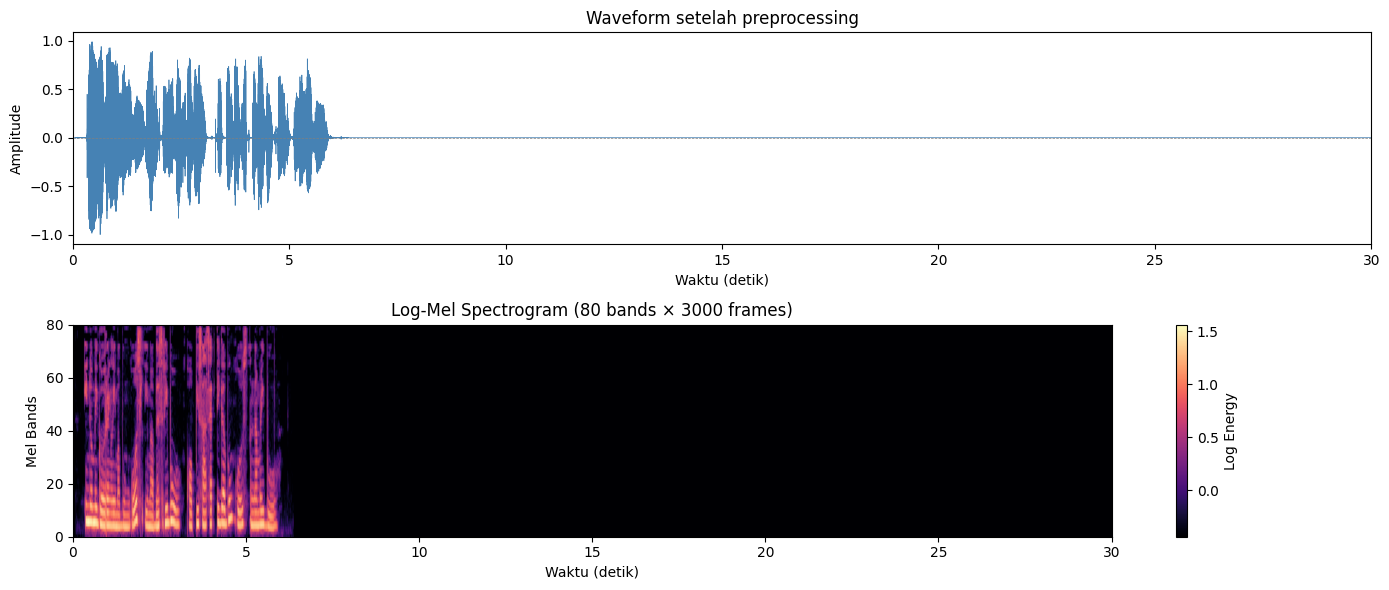

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6))

# Waveform
axes[0].plot(np.linspace(0, len(audio_padded)/TARGET_SR, len(audio_padded)),
             audio_padded, linewidth=0.5, color='steelblue')
axes[0].set_title("Waveform setelah preprocessing", fontsize=12)
axes[0].set_xlabel("Waktu (detik)")
axes[0].set_ylabel("Amplitude")
axes[0].set_xlim([0, 30])
axes[0].axhline(0, color='gray', linewidth=0.5, linestyle='--')

# Log-Mel Spectrogram
mel_np = mel_tensor.numpy()
img = axes[1].imshow(mel_np, aspect='auto', origin='lower',
                     extent=[0, 30, 0, 80], cmap='magma')
axes[1].set_title("Log-Mel Spectrogram (80 bands × 3000 frames)", fontsize=12)
axes[1].set_xlabel("Waktu (detik)")
axes[1].set_ylabel("Mel Bands")
plt.colorbar(img, ax=axes[1], label="Log Energy")

plt.tight_layout()
plt.savefig("savefig/preprocessing_output.png", dpi=150, bbox_inches='tight')
plt.show()

# Encoder/Decoder (Whisper)

In [7]:
MODEL_SIZE = "small"
LANGUAGE   = "id"
device = "cuda" if torch.cuda.is_available() else "cpu"
model  = whisper.load_model(MODEL_SIZE, device=device) 

In [8]:
print(f"model size: {MODEL_SIZE}, language: {LANGUAGE}, device: {device}")

model size: small, language: id, device: cuda


In [9]:
mel_input = mel_tensor.unsqueeze(0).to(device)   

with torch.no_grad():
    audio_features = model.encoder(mel_input)    

print(f"Input shape : {mel_input.shape}")
print(f"Audio features shape : {audio_features.shape}")

Input shape : torch.Size([1, 80, 3000])
Audio features shape : torch.Size([1, 1500, 768])


In [10]:
options = whisper.DecodingOptions(
    language           = LANGUAGE,
    without_timestamps = False, 
    beam_size          = 5,          
    temperature        = 0.0,
    fp16               = True if device == "cuda" else False
)
with torch.no_grad():
    decode_result = whisper.decode(model, mel_tensor.to(device), options)

# Raw token IDs sebelum dikonversi ke teks
raw_tokens = decode_result.tokens
print(f"Jumlah token    : {len(raw_tokens)}")
print(f"Token IDs (raw) : {raw_tokens[:20]} ...")
print(f"Log probability : {decode_result.avg_logprob:.4f}")
print(f"No speech prob  : {decode_result.no_speech_prob:.4f}")

Jumlah token    : 25
Token IDs (raw) : [50364, 2333, 40120, 352, 265, 872, 1025, 50045, 35080, 2119, 9162, 84, 11, 28920, 72, 262, 296, 302, 805, 50045] ...
Log probability : -0.3832
No speech prob  : 0.0057


In [11]:
# tokenizer Whisper
tokenizer = whisper.tokenizer.get_tokenizer(
    multilingual = True,
    language     = LANGUAGE,
    task         = "transcribe"
)

# special tokens (timestamp, SOT, EOT)
SPECIAL_TOKEN_IDS = set(tokenizer.sot_sequence) | {
    tokenizer.eot,
    tokenizer.no_speech,
    tokenizer.translate,
    tokenizer.transcribe,
}

# timestamp token range: 50364 – 51865
filtered_tokens = [
    t for t in raw_tokens
    if t not in SPECIAL_TOKEN_IDS and not (50264 <= t <= 51865)
]

# Decode token-by-token
token_to_str_map = {}
for i, token_id in enumerate(filtered_tokens[:15]):
    substr = tokenizer.decode([token_id])
    token_to_str_map[token_id] = substr
    print(f"  Token[{i:02d}] ID={token_id:6d} → '{substr}'")

# Decode semua token
full_text = tokenizer.decode(filtered_tokens)
print(f"\n Full string ({len(full_text)} karakter):")
print("-" * 60)
print(full_text)
print("-" * 60)

  Token[00] ID=  2333 → ' Ind'
  Token[01] ID= 40120 → 'omie'
  Token[02] ID=   352 → ' go'
  Token[03] ID=   265 → 're'
  Token[04] ID=   872 → 'ng'
  Token[05] ID=  1025 → ' 5'
  Token[06] ID= 50045 → ' bung'
  Token[07] ID= 35080 → 'kus'
  Token[08] ID=  2119 → ' 15'
  Token[09] ID=  9162 → ' rib'
  Token[10] ID=    84 → 'u'
  Token[11] ID=    11 → ','
  Token[12] ID= 28920 → ' kop'
  Token[13] ID=    72 → 'i'
  Token[14] ID=   262 → ' s'

 Full string (62 karakter):
------------------------------------------------------------
 Indomie goreng 5 bungkus 15 ribu, kopi saset 3 bungkus 6 ribu
------------------------------------------------------------


In [12]:
import re

def clean_transcript(text: str) -> str:
    text = re.sub(r'\[\d{2}:\d{2}\.\d{3} --> \d{2}:\d{2}\.\d{3}\]', '', text)
    # Hapus spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()
    # Perbaiki tanda baca
    text = re.sub(r'\s([?.!,;:])', r'\1', text)
    return text

final_string = clean_transcript(full_text)
print(f"{len(final_string)} karakter: {(final_string)}")


61 karakter: Indomie goreng 5 bungkus 15 ribu, kopi saset 3 bungkus 6 ribu


# Token Map Visualization

In [13]:
tokenizer_debug = whisper.tokenizer.get_tokenizer(
    multilingual=True, language="id", task="transcribe"
)

all_tokens     = decode_result.tokens
all_substrings = [tokenizer_debug.decode([t]) for t in all_tokens]

print(f"{'Index':>4} │ {'Token ID':>8} │ {'Substring':>20} │ Tipe")
print("─" * 55)
for i, (tid, sub) in enumerate(zip(all_tokens, all_substrings)):
    if 50264 <= tid <= 51865:
        tipe = "timestamp"
    elif tid in {tokenizer_debug.eot}:
        tipe = "EOT"
    elif tid in set(tokenizer_debug.sot_sequence):
        tipe = "SOT/LANG"
    else:
        tipe = "text"
    print(f"{i:>4} │ {tid:>8} │ {repr(sub):>20} │ {tipe}")
    if i >= 30:
        print(f"  ... ({len(all_tokens)-31} token lainnya)")
        break

Index │ Token ID │            Substring │ Tipe
───────────────────────────────────────────────────────
   0 │    50364 │                   '' │ timestamp
   1 │     2333 │               ' Ind' │ text
   2 │    40120 │               'omie' │ text
   3 │      352 │                ' go' │ text
   4 │      265 │                 're' │ text
   5 │      872 │                 'ng' │ text
   6 │     1025 │                 ' 5' │ text
   7 │    50045 │              ' bung' │ text
   8 │    35080 │                'kus' │ text
   9 │     2119 │                ' 15' │ text
  10 │     9162 │               ' rib' │ text
  11 │       84 │                  'u' │ text
  12 │       11 │                  ',' │ text
  13 │    28920 │               ' kop' │ text
  14 │       72 │                  'i' │ text
  15 │      262 │                 ' s' │ text
  16 │      296 │                 'as' │ text
  17 │      302 │                 'et' │ text
  18 │      805 │                 ' 3' │ text
  19 │    50045 │ 

# Ektrasi Audio Length

In [14]:
MODEL_SIZE = "small"
LANGUAGE   = "id"
device = "cuda" if torch.cuda.is_available() else "cpu"
model  = whisper.load_model(MODEL_SIZE, device=device) 

In [15]:
initial_prompt = "Berikut pesanan sembako: beras 2 kilo harga 25.000. Total belanja 1.500.000 atau 150.000."

In [16]:
result = model.transcribe(
    audio_file,
    language="id",
    temperature=0.0,
    initial_prompt=initial_prompt
)

clean_text = result["text"].strip()

clean_text = text_cleaning(clean_text)

In [17]:
clean_text

'indomie goreng 5 bungkus 15.000, kopi saset 3 bungkus 6.000.'